# 05 Pierwsze modele dla `event_threshold_10`

Celem notebooka jest pierwsze, minimalistyczne porównanie modeli predykcyjnych dla ryzyka przyszłego spadku behawioralnej ciągłości pracy.

Nie robimy jeszcze tuningu hiperparametrów ani interpretacji SHAP. Najpierw sprawdzamy:

- czy modele biją sensowne baseline’y,
- czy wynik jest stabilny między validation i test,
- czy wynik nie rozpada się per użytkownik,
- czy `behavior_primary` daje wartość ponad prosty baseline autoregresyjny z bieżącego `BWCI_pu`.

Główny target: `event_threshold_10`. Dodatni przypadek oznacza, że przyszły `BWCI_pu` za 10 obserwowanych rekordów spada poniżej dolnego kwartylu danego użytkownika.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  average_precision_score,
  balanced_accuracy_score,
  brier_score_loss,
  f1_score,
  precision_score,
  recall_score,
  roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATASET_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1.parquet"
METADATA_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1_metadata.json"
RESULTS_PATH = OUTPUT_DIR / "model_results_event_threshold_10_v0_1.csv"
PER_USER_RESULTS_PATH = OUTPUT_DIR / "model_results_event_threshold_10_v0_1_per_user.csv"

RANDOM_STATE = 42
THRESHOLD = 0.50

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Wczytanie datasetu modelowego

Notebook 05 korzysta z artefaktu przygotowanego w notebooku 04. Dzięki temu nie przeliczamy BWCI od zera przy każdym porównaniu modeli.

Wczytujemy też metadata z definicją targetu i zestawów cech, żeby notebook nie opierał się na ręcznie przepisanych listach kolumn.


In [2]:
if not DATASET_PATH.exists():
  raise FileNotFoundError(f"Missing model dataset: {DATASET_PATH}")
if not METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing model metadata: {METADATA_PATH}")

model_dataset = pd.read_parquet(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text())

TARGET_COL = str(metadata["classification_target"])
REGRESSION_TARGET_COL = str(metadata["regression_target"])
feature_sets: dict[str, list[str]] = metadata["feature_sets"]

load_summary = pd.DataFrame(
  [
    {
      "rows": len(model_dataset),
      "users": model_dataset["USER"].nunique(),
      "columns": len(model_dataset.columns),
      "target": TARGET_COL,
      "positive_pct": model_dataset[TARGET_COL].mean() * 100,
      "splits": ", ".join(sorted(model_dataset["temporal_split"].unique())),
    }
  ]
)
load_summary


,rows,users,columns,target,positive_pct,splits
0,76039,11,41,event_threshold_10,20.5644,"test, train, validation"


In [3]:
split_summary = (
  model_dataset.groupby("temporal_split")
  .agg(
    rows=(TARGET_COL, "size"),
    users=("USER", "nunique"),
    positive_pct=(TARGET_COL, lambda values: values.mean() * 100),
    start=("datetime", "min"),
    end=("datetime", "max"),
  )
  .reset_index()
)
split_summary


,temporal_split,rows,users,positive_pct,start,end
0,test,15212,11,23.5801,2019-12-05 14:20:45.071,2020-01-14 09:43:38.352
1,train,45621,11,20.0281,2019-11-20 12:08:51.669,2020-01-10 21:06:01.996
2,validation,15206,11,19.1569,2019-12-03 15:22:00.529,2020-01-12 22:58:05.640


### Interpretacja danych wejściowych

Dataset ma wystarczająco dużo obserwacji do pierwszego benchmarku, a dodatnia klasa pozostaje umiarkowanie niezbalansowana. Z tego powodu główną metryką pomocniczą będzie AUC-PR, nie tylko AUC-ROC.

Split czasowy zachowujemy bez mieszania rekordów między przyszłością i przeszłością per użytkownik. To nie rozwiązuje wszystkich ryzyk metodologicznych, ale jest minimalnym warunkiem uczciwego pierwszego porównania.


## Sekcja 2: Modele i metryki

Porównujemy cztery grupy:

- `dummy_prior`: stały baseline częstości klasy pozytywnej,
- `autoregressive_lr`: baseline z bieżącego `BWCI_pu`,
- modele na `behavior_primary`: główne modele bez bieżącego BWCI,
- `behavior_plus_bwci_lr`: wariant diagnostyczny z bieżącym BWCI dodanym do telemetrycznych cech.

Dla klasyfikacji raportujemy AUC-ROC, AUC-PR, Brier score oraz metryki progowe przy `0.50`. Próg `0.50` nie jest jeszcze optymalizowany; w tym notebooku służy tylko do pierwszej orientacji.


In [4]:
def make_scaled_logistic_pipeline(class_weight: str | None = "balanced") -> Pipeline:
  """ Create a median-imputed, scaled logistic regression pipeline.

    Args:
      class_weight: Class weighting strategy passed to LogisticRegression.

    Returns:
      Pipeline: Scikit-learn pipeline for logistic regression.
  """
  return Pipeline(
    steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      (
        "model",
        LogisticRegression(
          max_iter=1000,
          class_weight=class_weight,
          random_state=RANDOM_STATE,
          solver="lbfgs",
        ),
      ),
    ]
  )


def make_tree_imputer_pipeline(model: BaseEstimator) -> Pipeline:
  """ Create a median-imputed tree-model pipeline.

    Args:
      model: Scikit-learn tree-based classifier.

    Returns:
      Pipeline: Pipeline with median imputation and the provided model.
  """
  return Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("model", model)])


def get_xy(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, pd.Series]:
  """ Extract feature matrix and target vector.

    Args:
      df: Modeling dataset.
      features: Feature column names.

    Returns:
      tuple[pd.DataFrame, pd.Series]: X and y.
  """
  return df[features], df[TARGET_COL].astype(int)


models: dict[str, tuple[BaseEstimator, list[str], str]] = {
  "dummy_prior": (DummyClassifier(strategy="prior"), feature_sets["baseline_autoregressive"], "baseline"),
  "autoregressive_lr": (make_scaled_logistic_pipeline(), feature_sets["baseline_autoregressive"], "baseline"),
  "behavior_logistic_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_primary"], "primary"),
  "behavior_random_forest": (
    make_tree_imputer_pipeline(
      RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
      )
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_hist_gradient_boosting": (
    make_tree_imputer_pipeline(
      HistGradientBoostingClassifier(
        max_iter=120,
        learning_rate=0.06,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
      )
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_plus_bwci_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_plus_bwci"], "diagnostic"),
}

model_table = pd.DataFrame(
  [
    {"model": name, "feature_count": len(features), "model_group": group}
    for name, (_, features, group) in models.items()
  ]
)
model_table


,model,feature_count,model_group
0,dummy_prior,1,baseline
1,autoregressive_lr,1,baseline
2,behavior_logistic_lr,21,primary
3,behavior_random_forest,21,primary
4,behavior_hist_gradient_boosting,21,primary
5,behavior_plus_bwci_lr,22,diagnostic


In [5]:
def score_predictions(y_true: pd.Series, y_proba: np.ndarray, threshold: float = THRESHOLD) -> dict[str, float]:
  """ Compute classification metrics for probability predictions.

    Args:
      y_true: Binary ground-truth labels.
      y_proba: Predicted probability for the positive class.
      threshold: Decision threshold for class labels.

    Returns:
      dict[str, float]: Classification metrics.
  """
  y_true_arr = np.asarray(y_true).astype(int)
  y_pred = (y_proba >= threshold).astype(int)
  unique_classes = np.unique(y_true_arr)

  tp = int(((y_true_arr == 1) & (y_pred == 1)).sum())
  fp = int(((y_true_arr == 0) & (y_pred == 1)).sum())
  tn = int(((y_true_arr == 0) & (y_pred == 0)).sum())
  fn = int(((y_true_arr == 1) & (y_pred == 0)).sum())

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
  specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
  f1 = 2 * precision * recall / (precision + recall) if pd.notna(recall) and (precision + recall) > 0 else np.nan
  balanced = np.nanmean([recall, specificity]) if len(unique_classes) == 2 else np.nan

  roc_auc = roc_auc_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan
  auc_pr = average_precision_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan
  return {
    "roc_auc": roc_auc,
    "auc_pr": auc_pr,
    "brier": brier_score_loss(y_true_arr, y_proba),
    "balanced_accuracy": balanced,
    "precision_pos": precision,
    "recall_pos": recall,
    "f1_pos": f1,
    "predicted_positive_pct": y_pred.mean() * 100,
  }


def predict_positive_probability(model: BaseEstimator, x_values: pd.DataFrame) -> np.ndarray:
  """ Predict positive-class probability from a fitted classifier.

    Args:
      model: Fitted scikit-learn classifier.
      x_values: Feature matrix.

    Returns:
      np.ndarray: Positive-class probabilities.
  """
  if hasattr(model, "predict_proba"):
    return model.predict_proba(x_values)[:, 1]
  decision = model.decision_function(x_values)
  return 1.0 / (1.0 + np.exp(-decision))


def evaluate_model_on_splits(name: str, model: BaseEstimator, features: list[str], train_df: pd.DataFrame, eval_df: pd.DataFrame, split_name: str) -> dict[str, object]:
  """ Fit a model on train data and evaluate it on one split.

    Args:
      name: Model name.
      model: Unfitted scikit-learn classifier.
      features: Feature columns.
      train_df: Training dataset.
      eval_df: Evaluation dataset.
      split_name: Name of the evaluated split.

    Returns:
      dict[str, object]: Metrics and metadata.
  """
  fitted = clone(model)
  x_train, y_train = get_xy(train_df, features)
  x_eval, y_eval = get_xy(eval_df, features)
  fitted.fit(x_train, y_train)
  y_proba = predict_positive_probability(fitted, x_eval)
  metrics = score_predictions(y_eval, y_proba)
  return {
    "model": name,
    "split": split_name,
    "rows": len(eval_df),
    "positive_pct": y_eval.mean() * 100,
    **metrics,
  }


train_df = model_dataset[model_dataset["temporal_split"] == "train"].copy()
validation_df = model_dataset[model_dataset["temporal_split"] == "validation"].copy()
test_df = model_dataset[model_dataset["temporal_split"] == "test"].copy()

result_rows: list[dict[str, object]] = []
fitted_models: dict[str, BaseEstimator] = {}
for name, (model, features, group) in models.items():
  fitted = clone(model)
  x_train, y_train = get_xy(train_df, features)
  fitted.fit(x_train, y_train)
  fitted_models[name] = fitted

  for split_name, eval_df in [("validation", validation_df), ("test", test_df)]:
    x_eval, y_eval = get_xy(eval_df, features)
    y_proba = predict_positive_probability(fitted, x_eval)
    result_rows.append(
      {
        "model": name,
        "model_group": group,
        "split": split_name,
        "rows": len(eval_df),
        "positive_pct": y_eval.mean() * 100,
        **score_predictions(y_eval, y_proba),
      }
    )

results_df = pd.DataFrame(result_rows).sort_values(["split", "auc_pr"], ascending=[True, False])
results_df


,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
7,behavior_random_forest,primary,test,15212,23.5801,0.7477,0.4220,0.2036,0.6883,0.3707,0.7909,0.5048,50.3155
11,behavior_plus_bwci_lr,diagnostic,test,15212,23.5801,0.7313,0.4031,0.2249,0.6705,0.3441,0.8277,0.4861,56.7184
9,behavior_hist_gradient_boosting,primary,test,15212,23.5801,0.7333,0.3976,0.1591,0.5127,0.4444,0.0413,0.0755,2.1891
5,behavior_logistic_lr,primary,test,15212,23.5801,0.7182,0.3861,0.2317,0.6636,0.3330,0.8567,0.4796,60.6692
3,autoregressive_lr,baseline,test,15212,23.5801,0.6354,0.3321,0.2382,0.6060,0.3168,0.6337,0.4224,47.1667
1,dummy_prior,baseline,test,15212,23.5801,0.5000,0.2358,0.1815,0.5000,0.0000,0.0000,NaN,0.0000
6,behavior_random_forest,primary,validation,15206,19.1569,0.7331,0.3239,0.1951,0.6693,0.3142,0.7013,0.4339,42.7660
10,behavior_plus_bwci_lr,diagnostic,validation,15206,19.1569,0.7222,0.3233,0.2241,0.6696,0.2942,0.7861,0.4281,51.1969
4,behavior_logistic_lr,primary,validation,15206,19.1569,0.7169,0.3218,0.2293,0.6660,0.2852,0.8174,0.4229,54.8994
8,behavior_hist_gradient_boosting,primary,validation,15206,19.1569,0.7177,0.3064,0.1430,0.5064,0.2904,0.0302,0.0547,1.9926


### Interpretacja pierwszego porównania

Pierwsza tabela pokazuje, że modele uczą się sygnału ponad dummy baseline. Na validation najlepszy jest `behavior_random_forest` z AUC-PR `0.3239` wobec `0.1916` dla `dummy_prior`; na test również wygrywa `behavior_random_forest` z AUC-PR `0.4220` wobec `0.2358` dla `dummy_prior`.

Autoregresja jest mocnym baseline’em, ale w temporal split nie wygrywa. `autoregressive_lr` ma AUC-PR `0.2545` na validation i `0.3321` na test, czyli mniej niż najlepszy model primary. To oznacza, że w scenariuszu znanych użytkowników surowe cechy telemetryczne dodają informację ponad bieżący `BWCI_pu`.

Różnica między validation i test jest zauważalna: dla `behavior_random_forest` AUC-PR rośnie z `0.3239` do `0.4220`. Ponieważ positive rate też rośnie z `19.16%` do `23.58%`, wynik testowy nie powinien być interpretowany bez kontroli per-user.


## Sekcja 3: Wyniki testowe i ranking modeli

Poniższa tabela zawęża porównanie do splitu testowego. Na tym etapie nie wybieramy jeszcze modelu finalnego, ale wskazujemy kandydatów do dalszej analizy.


In [6]:
test_results = results_df[results_df["split"] == "test"].sort_values("auc_pr", ascending=False).reset_index(drop=True)
test_results


,model,model_group,split,rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
0,behavior_random_forest,primary,test,15212,23.5801,0.7477,0.4220,0.2036,0.6883,0.3707,0.7909,0.5048,50.3155
1,behavior_plus_bwci_lr,diagnostic,test,15212,23.5801,0.7313,0.4031,0.2249,0.6705,0.3441,0.8277,0.4861,56.7184
2,behavior_hist_gradient_boosting,primary,test,15212,23.5801,0.7333,0.3976,0.1591,0.5127,0.4444,0.0413,0.0755,2.1891
3,behavior_logistic_lr,primary,test,15212,23.5801,0.7182,0.3861,0.2317,0.6636,0.3330,0.8567,0.4796,60.6692
4,autoregressive_lr,baseline,test,15212,23.5801,0.6354,0.3321,0.2382,0.6060,0.3168,0.6337,0.4224,47.1667
5,dummy_prior,baseline,test,15212,23.5801,0.5000,0.2358,0.1815,0.5000,0.0000,0.0000,NaN,0.0000


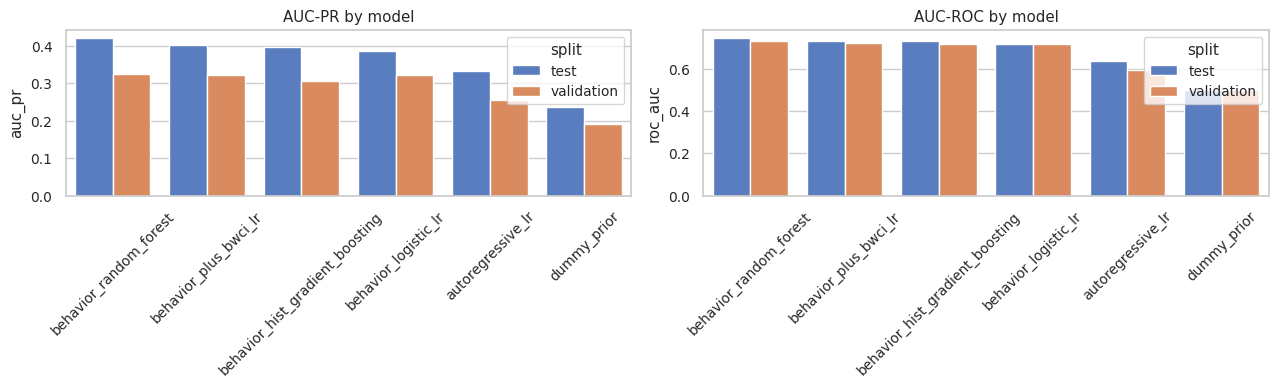

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_data = results_df.copy()
sns.barplot(data=plot_data, x="model", y="auc_pr", hue="split", ax=axes[0])
axes[0].set_title("AUC-PR by model")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=plot_data, x="model", y="roc_auc", hue="split", ax=axes[1])
axes[1].set_title("AUC-ROC by model")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


In [8]:
test_metric_lookup = test_results.set_index("model")
best_primary_row = test_results[test_results["model_group"] == "primary"].sort_values("auc_pr", ascending=False).iloc[0]
key_comparison_summary = pd.DataFrame(
  [
    {
      "comparison": "best_primary_vs_dummy_prior_auc_pr",
      "best_primary_model": best_primary_row["model"],
      "delta_auc_pr": best_primary_row["auc_pr"] - test_metric_lookup.loc["dummy_prior", "auc_pr"],
    },
    {
      "comparison": "best_primary_vs_autoregressive_auc_pr",
      "best_primary_model": best_primary_row["model"],
      "delta_auc_pr": best_primary_row["auc_pr"] - test_metric_lookup.loc["autoregressive_lr", "auc_pr"],
    },
    {
      "comparison": "best_primary_vs_behavior_plus_bwci_auc_pr",
      "best_primary_model": best_primary_row["model"],
      "delta_auc_pr": best_primary_row["auc_pr"] - test_metric_lookup.loc["behavior_plus_bwci_lr", "auc_pr"],
    },
  ]
)
key_comparison_summary


,comparison,best_primary_model,delta_auc_pr
0,best_primary_vs_dummy_prior_auc_pr,behavior_random_forest,0.1862
1,best_primary_vs_autoregressive_auc_pr,behavior_random_forest,0.0899
2,best_primary_vs_behavior_plus_bwci_auc_pr,behavior_random_forest,0.0189


### Interpretacja porównań testowych

Na teście najlepszy model primary to `behavior_random_forest`. Jego przewaga AUC-PR nad `dummy_prior` wynosi `+0.1862`, a nad `autoregressive_lr` `+0.0899`. To jest główny pozytywny wynik notebooka 05: w temporal split model telemetryczny przewiduje `event_threshold_10` lepiej niż sama częstość klasy i lepiej niż bieżący `BWCI_pu`.

Wariant diagnostyczny `behavior_plus_bwci_lr` ma AUC-PR `0.4031`, czyli mniej niż `behavior_random_forest` (`0.4220`). Dodanie bieżącego BWCI do regresji logistycznej nie daje tu zwycięstwa nad najlepszym modelem primary, więc nie ma powodu przenosić `BWCI_pu` do głównego zestawu cech na tym etapie.


### Interpretacja rankingu

Ranking testowy wskazuje `behavior_random_forest` jako najlepszy model tej iteracji: AUC-PR `0.4220`, AUC-ROC `0.7477`, balanced accuracy `0.6883` i recall klasy pozytywnej `0.7909`. Model jest jednak dość agresywny: przewiduje klasę pozytywną dla `50.32%` obserwacji, przy rzeczywistym positive rate `23.58%`.

`behavior_hist_gradient_boosting` ma podobny AUC-ROC (`0.7333`) i AUC-PR `0.3976`, ale przy progu `0.50` prawie nie oznacza klasy pozytywnej: recall wynosi tylko `0.0413`, a predicted positive rate `2.19%`. To oznacza, że jego ranking może być użyteczny, ale próg decyzyjny jest źle dobrany.

Decyzja: `behavior_random_forest` zostaje najlepszym modelem primary dla tej iteracji, a w kolejnych krokach trzeba rozdzielać ocenę rankingu od oceny twardej klasyfikacji przy progu `0.50`.


## Sekcja 4: Wyniki per użytkownik na teście

Globalny wynik może ukrywać użytkowników, dla których target jest bardzo rzadki albo model działa słabo. Dlatego raportujemy testowe metryki per użytkownik dla wszystkich modeli.


In [9]:
def evaluate_per_user(model_name: str, fitted_model: BaseEstimator, features: list[str], eval_df: pd.DataFrame) -> pd.DataFrame:
  """ Evaluate a fitted model separately for each user.

    Args:
      model_name: Model name.
      fitted_model: Fitted classifier.
      features: Feature columns.
      eval_df: Evaluation dataset.

    Returns:
      pd.DataFrame: Per-user metric table.
  """
  rows: list[dict[str, object]] = []
  for uid, user_df in eval_df.groupby("USER"):
    x_user, y_user = get_xy(user_df, features)
    y_proba = predict_positive_probability(fitted_model, x_user)
    metrics = score_predictions(y_user, y_proba)
    rows.append(
      {
        "model": model_name,
        "USER": int(uid),
        "rows": len(user_df),
        "positive_rows": int(y_user.sum()),
        "positive_pct": y_user.mean() * 100,
        **metrics,
      }
    )
  return pd.DataFrame(rows)


per_user_frames: list[pd.DataFrame] = []
for name, (_, features, _) in models.items():
  per_user_frames.append(evaluate_per_user(name, fitted_models[name], features, test_df))

per_user_results = pd.concat(per_user_frames, ignore_index=True)
per_user_results.sort_values(["model", "USER"]).head(30)


,model,USER,rows,positive_rows,positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
11,autoregressive_lr,0,1063,350,32.9257,0.6094,0.4277,0.2501,0.5885,0.3952,0.7114,0.5082,59.2662
12,autoregressive_lr,1,2690,0,0.0000,NaN,NaN,0.2480,NaN,0.0000,NaN,NaN,44.3123
13,autoregressive_lr,3,628,168,26.7516,0.6977,0.5021,0.2168,0.6227,0.3902,0.5714,0.4638,39.1720
14,autoregressive_lr,4,1622,473,29.1615,0.6059,0.3804,0.2421,0.5778,0.3586,0.5899,0.4460,47.9655
15,autoregressive_lr,5,345,96,27.8261,0.6972,0.4607,0.2199,0.6190,0.3944,0.5833,0.4706,41.1594
16,autoregressive_lr,6,197,91,46.1929,0.7449,0.6530,0.2185,0.6895,0.5890,0.9451,0.7257,74.1117
17,autoregressive_lr,7,712,172,24.1573,0.5605,0.2669,0.2427,0.5438,0.2812,0.4709,0.3522,40.4494
18,autoregressive_lr,8,856,293,34.2290,0.6088,0.3955,0.2444,0.6206,0.4345,0.7474,0.5496,58.8785
19,autoregressive_lr,9,1149,226,19.6693,0.6109,0.2689,0.2340,0.5995,0.2757,0.5575,0.3690,39.7737
20,autoregressive_lr,10,2585,555,21.4700,0.6489,0.3155,0.2243,0.6004,0.3048,0.5333,0.3879,37.5629


In [10]:
best_primary_model = (
  test_results[test_results["model_group"] == "primary"]
  .sort_values("auc_pr", ascending=False)
  .iloc[0]["model"]
)

best_primary_per_user = per_user_results[per_user_results["model"] == best_primary_model].sort_values("auc_pr", ascending=False)
best_primary_model, best_primary_per_user


('behavior_random_forest',
                      model  USER  rows  positive_rows  positive_pct  roc_auc  \
 38  behavior_random_forest     6   197             91       46.1929   0.7274   
 37  behavior_random_forest     5   345             96       27.8261   0.7507   
 43  behavior_random_forest    11  3365           1163       34.5617   0.7096   
 33  behavior_random_forest     0  1063            350       32.9257   0.6250   
 35  behavior_random_forest     3   628            168       26.7516   0.6753   
 40  behavior_random_forest     8   856            293       34.2290   0.6213   
 36  behavior_random_forest     4  1622            473       29.1615   0.5398   
 42  behavior_random_forest    10  2585            555       21.4700   0.6757   
 41  behavior_random_forest     9  1149            226       19.6693   0.6911   
 39  behavior_random_forest     7   712            172       24.1573   0.6391   
 34  behavior_random_forest     1  2690              0        0.0000      NaN   
 

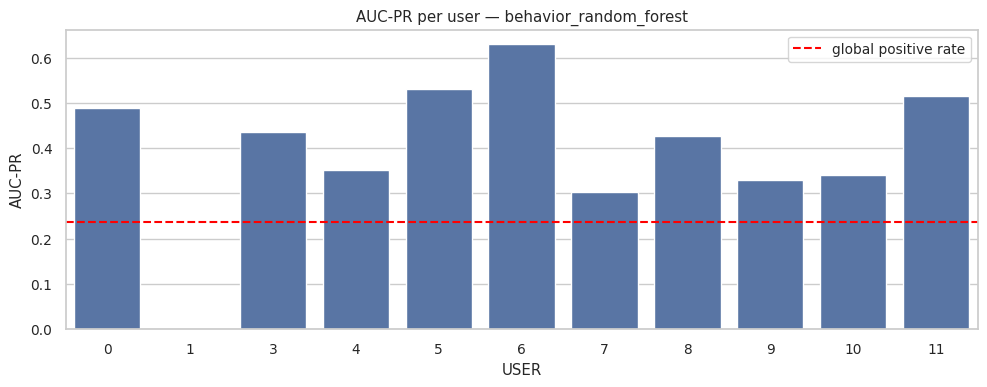

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=best_primary_per_user, x="USER", y="auc_pr", ax=ax, color="#4C72B0")
ax.axhline(test_df[TARGET_COL].mean(), color="red", linestyle="--", label="global positive rate")
ax.set_title(f"AUC-PR per user: {best_primary_model}")
ax.set_ylabel("AUC-PR")
ax.legend()
fig.tight_layout()
plt.show()


### Interpretacja per-user

Per-user wyniki pokazują, że globalna jakość `behavior_random_forest` nie jest równomierna. Dla User 6 AUC-PR wynosi `0.6299`, dla User 5 `0.5297`, a dla User 11 `0.5157`. Słabsze wyniki pojawiają się m.in. dla User 7 (`0.3025`), User 9 (`0.3290`) i User 10 (`0.3400`).

User 1 jest przypadkiem szczególnym: w testowym fragmencie ma `0` pozytywnych przypadków, więc AUC-PR i AUC-ROC są niezdefiniowane. To nie jest tylko problem modelu, ale sygnał, że target progowy może zachowywać się patologicznie dla części użytkowników.

Wniosek: wyniki globalne z temporal split trzeba uzupełnić LOGO i audytem targetu. Sam test globalny sugeruje dobry model, ale analiza per-user pokazuje, że target i generalizacja między użytkownikami wymagają osobnej kontroli.


## Sekcja 5: Prosta interpretacja cech

Na tym etapie nie robimy SHAP ani pełnej analizy interpretowalności. Wystarczy szybki podgląd:

- współczynniki Logistic Regression dla `behavior_primary`,
- importance z Random Forest, jeśli model jest dostępny.

To nie jest jeszcze dowód przyczynowy. To tylko kontrola, czy modele korzystają z sensownych sygnałów.


In [12]:
def logistic_coefficients(pipeline: Pipeline, features: list[str]) -> pd.DataFrame:
  """ Extract logistic regression coefficients from a fitted pipeline.

    Args:
      pipeline: Fitted pipeline ending with LogisticRegression.
      features: Feature names.

    Returns:
      pd.DataFrame: Coefficients sorted by absolute magnitude.
  """
  model = pipeline.named_steps["model"]
  coefs = model.coef_[0]
  return (
    pd.DataFrame({"feature": features, "coefficient": coefs, "abs_coefficient": np.abs(coefs)})
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
  )


behavior_lr_coefficients = logistic_coefficients(fitted_models["behavior_logistic_lr"], feature_sets["behavior_primary"])
behavior_lr_coefficients.head(15)


,feature,coefficient,abs_coefficient
0,active_apps_mean,-1.7132,1.7132
1,keystroke_sum,-0.3255,0.3255
2,idle_ratio,0.2892,0.2892
3,word_sum,0.2140,0.2140
4,press_press_std,-0.1943,0.1943
5,input_sum,-0.1648,0.1648
6,foreground_time_mean,-0.1633,0.1633
7,foreground_focus_share,-0.1633,0.1633
8,mouse_sum,-0.1576,0.1576
9,hour_cos,-0.1474,0.1474


In [13]:
def tree_feature_importance(pipeline: Pipeline, features: list[str]) -> pd.DataFrame:
  """ Extract feature importance from a fitted tree pipeline.

    Args:
      pipeline: Fitted pipeline ending with a tree classifier.
      features: Feature names.

    Returns:
      pd.DataFrame: Feature importance sorted descending.
  """
  model = pipeline.named_steps["model"]
  if not hasattr(model, "feature_importances_"):
    return pd.DataFrame(columns=["feature", "importance"])
  return (
    pd.DataFrame({"feature": features, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
  )


rf_importance = tree_feature_importance(fitted_models["behavior_random_forest"], feature_sets["behavior_primary"])
rf_importance.head(15)


,feature,importance
0,active_apps_mean,0.2414
1,mouse_sum,0.1158
2,input_sum,0.1129
3,hour_cos,0.0546
4,keystroke_sum,0.0527
5,hour_sin,0.0502
6,press_press_mean,0.0489
7,idle_ratio,0.0449
8,typing_cv,0.0392
9,press_press_std,0.0354


### Interpretacja cech

Regresja logistyczna najmocniej waży `active_apps_mean` (`-1.7132`), a dalej cechy aktywności wejścia, takie jak `keystroke_sum`, `idle_ratio`, `word_sum`, `press_press_std` i `input_sum`. To jest spójne z BWCI jako proxy zachowania przy komputerze, ale nie wolno interpretować tych współczynników jako pomiaru skupienia psychologicznego.

Random Forest również najwyżej ocenia `active_apps_mean` (`0.2414`), następnie `mouse_sum` (`0.1158`), `input_sum` (`0.1129`), cechy czasu (`hour_cos`, `hour_sin`) oraz aktywność klawiatury. Model korzysta więc zarówno z intensywności interakcji, jak i rytmów czasowych.

Obecność cech czasu w ważnych predyktorach oznacza, że kolejne etapy powinny sprawdzić stabilność czasową i per-user. Model może częściowo uczyć się regularności harmonogramu danych, nie tylko bezpośredniego wzorca przerwania pracy.


## Sekcja 6: Zapis wyników i decyzje

Zapisujemy wyniki do `outputs/`, żeby kolejny etap mógł porównać tuning lub inne targety bez przepisywania tabel z notebooka.


In [14]:
results_df.to_csv(RESULTS_PATH, index=False)
per_user_results.to_csv(PER_USER_RESULTS_PATH, index=False)

print(f"Saved model results: {RESULTS_PATH}")
print(f"Saved per-user results: {PER_USER_RESULTS_PATH}")


Saved model results: /home/sefni/git/bwci-thesis/outputs/model_results_event_threshold_10_v0_1.csv
Saved per-user results: /home/sefni/git/bwci-thesis/outputs/model_results_event_threshold_10_v0_1_per_user.csv


## Decyzje po notebooku 05

Po pierwszym benchmarku dla `event_threshold_10` odpowiedzi na pytania decyzyjne są następujące:

1. `behavior_primary` bije `dummy_prior`. Najlepszy model primary, `behavior_random_forest`, uzyskał na teście AUC-PR `0.4220` wobec `0.2358` dla `dummy_prior`, czyli różnica wynosi `+0.1862`. To oznacza, że surowe cechy telemetryczne zawierają sygnał predykcyjny dla tego targetu.
2. `behavior_primary` bije też baseline autoregresyjny na temporal test. `behavior_random_forest` ma AUC-PR `0.4220`, a `autoregressive_lr` `0.3321`, czyli różnica wynosi `+0.0899`. W scenariuszu czasowym dla znanych użytkowników model telemetryczny daje więc wartość ponad bieżący `BWCI_pu`.
3. Validation i test nie pokazują załamania rankingu, ale różnią się poziomem AUC-PR. Dla `behavior_random_forest` AUC-PR rośnie z `0.3239` na validation do `0.4220` na test. Część tej różnicy wynika z innej częstości klasy pozytywnej (`19.16%` vs `23.58%`), więc przed tuningiem potrzebna jest kontrola stabilności per user i LOGO.
4. Wyniki per użytkownik są nierówne. Dla najlepszego modelu primary AUC-PR waha się od około `0.3025` dla User 7 do `0.6299` dla User 6, a User 1 ma `0` pozytywnych przypadków w teście, więc AUC-PR i AUC-ROC są niezdefiniowane. To oznacza, że leave-one-user-out powinien być obowiązkowym elementem ewaluacji, nie dodatkiem.
5. Nie przechodzimy jeszcze do tuningu. Najpierw trzeba sprawdzić generalizację między użytkownikami i stabilność targetu. Późniejsze notebooki 06-08 potwierdzają tę decyzję: LOGO jest trudniejsze, a audyt targetu wskazuje, że `event_threshold_10` ma problem definicyjny dla User 1.

Decyzja robocza po notebooku 05: zachować `behavior_random_forest` jako najlepszy model primary dla tej iteracji, ale potraktować wyniki jako wstępny benchmark dla pierwotnego targetu, nie jako finalny wynik pracy.
